In [ ]:
%pip install torch torchvision opencv-python scikit-learn

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import torch.optim as optim
import cv2


In [20]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [21]:
train_dir = '/kaggle/naruto-hand-signs/data/train'
test_dir = '/kaggle/naruto-hand-signs/data/test'

In [23]:
# Creating more data 

# rotate
def rotate_image(image, angle):
  image_center = tuple(np.array(image.shape[1::-1]) / 2)
  rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
  result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)
  return result

# warp
def center_crop(img):
    """Returns center cropped image
    Args:
    img: image to be center cropped
    dim: dimensions (width, height) to be cropped
    """
    width, height = img.shape[1], img.shape[0]

    # process crop width and height for max available dimension
    crop_width = crop_height = width if width <= height else height
    mid_x, mid_y = int(width/2), int(height/2)
    cw2, ch2 = int(crop_width/2), int(crop_height/2) 
    crop_img = img[mid_y-ch2:mid_y+ch2, mid_x-cw2:mid_x+cw2]
    return crop_img


# scale
def center_crop(img):
    """Returns center cropped image
    Args:
    img: image to be center cropped
    dim: dimensions (width, height) to be cropped
    """
    width, height = img.shape[1], img.shape[0]

    # process crop width and height for max available dimension
    crop_width = crop_height = width if width <= height else height
    mid_x, mid_y = int(width/2), int(height/2)
    cw2, ch2 = int(crop_width/2), int(crop_height/2) 
    crop_img = img[mid_y-ch2:mid_y+ch2, mid_x-cw2:mid_x+cw2]
    return crop_img


def scale_image(img, factor=1):
    """Returns resize image by scale factor.
    This helps to retain resolution ratio while resizing.
    Args:
    img: image to be scaled
    factor: scale factor to resize
    """
    return cv2.resize(img,(int(img.shape[1]*factor), int(img.shape[0]*factor)))


In [24]:
import random

def get_data(data_dir) :
    images = []
    labels = []
    
    dir_list = os.listdir(data_dir)
    for i in range(len(dir_list)):
        print("Obtaining images of", dir_list[i], "...")
        for image in os.listdir(data_dir + "/" + dir_list[i]):
            img = cv2.imread(data_dir + '/' + dir_list[i] + '/' + image)
            for rep in range(3):
                clone = img.copy()
                clone = rotate_image(clone, random.randint(5,10))
                clone = scale_image(clone, 1 + random.randint(30, 600) / 100)
                clone = center_crop(clone)
                clone = cv2.resize(clone, (128, 128))
                images.append(clone)
                labels.append(i)
            
            img = cv2.resize(img, (128, 128))
            images.append(img)
            labels.append(i)
            
            
    
    return images, labels


train_dir = os.path.join("kaggle", "naruto-hand-signs", "data", "train")
test_dir = os.path.join("kaggle", "naruto-hand-signs", "data", "test")

X, y = get_data(train_dir)

print("ALL DONE!!")


Obtaining images of bird ...
Obtaining images of boar ...
Obtaining images of dog ...
Obtaining images of dragon ...
Obtaining images of hare ...
Obtaining images of horse ...
Obtaining images of monkey ...
Obtaining images of ox ...
Obtaining images of ram ...
Obtaining images of rat ...
Obtaining images of snake ...
Obtaining images of tiger ...
Obtaining images of zero ...
ALL DONE!!


<Figure size 640x480 with 0 Axes>

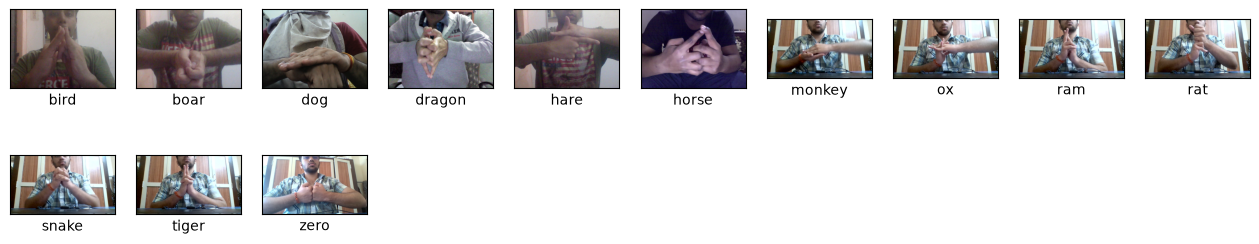

In [86]:

classes = ['bird', 'boar', 'dog', 'dragon', 'hare', 'horse', 'monkey', 'ox', 'ram', 'rat', 'snake', 
           'tiger', 'zero']

def plot_sample_images():
    figure = plt.figure()
    plt.figure(figsize=(16,5))

    for i in range (0,13):
        plt.subplot(3,10,i+1)
        plt.xticks([])
        plt.yticks([])
        dir_list = os.listdir(train_dir + f"/{classes[i]}")
        path = train_dir + f"/{classes[i]}/" + dir_list[0]
        img = plt.imread(path)
        plt.imshow(img)
        plt.xlabel(classes[i])
        
plot_sample_images()

In [25]:
print(len(X), len(y))

8636 8636


In [85]:
def preprocess_data(X, y):
    # Normalise and convert to float32 NumPy array

    global flag
    if flag == 0:
        print(y)
    else:
        flag +=1

    np_X = np.array(X).astype('float32') / 255.0
    np_y = np.array(y).astype('int64') # Keep as integers for PyTorch
    
    # Split raw arrays first
    x_train, x_test, y_train, y_test = train_test_split(
        np_X, np_y, test_size=0.01, random_state=42
    )
    
    # Convert images to tensors and permute axes to (Batch, Channels, Height, Width)
    x_train = torch.from_numpy(x_train).permute(0, 3, 1, 2)
    x_test = torch.from_numpy(x_test).permute(0, 3, 1, 2)
    
    # Convert labels directly to 1D LongTensors (No one-hot encoding)
    y_train = torch.from_numpy(y_train).long()
    y_test = torch.from_numpy(y_test).long()
    
    return x_train, x_test, y_train, y_test

flag = 0
# Execute native PyTorch preprocessing
x_train, x_test, y_train, y_test = preprocess_data(X, y)

print(y_test[0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [29]:
# Total Size
print("Training data:", x_train.shape)
print("Test data:", x_test.shape)

Training data: torch.Size([8549, 3, 128, 128])
Test data: torch.Size([87, 3, 128, 128])


#### Architecure 
4 layers 
- (conv2d -> activation=relu, max_pooling, batch_normalization) * 4


In [39]:
class Model(nn.Module):
    def __init__(self, classes=13):
        super(Model, self).__init__()
        self.Layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(64))

        self.Layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.Dropout(0.2))

        self.Layer3 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(256))


        self.Layer4 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
        )

        self.Layer5 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(1024),
        )

        self.Layer6 = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(in_features=16384, out_features=1024),
            nn.ReLU(),
            nn.Linear(in_features=1024, out_features=classes),
        )


    def forward(self, x):
        x = self.Layer1(x)
        x = self.Layer2(x)
        x = self.Layer3(x)
        x = self.Layer4(x)
        x = self.Layer5(x)
        x = self.Layer6(x)
        return x

model = Model()

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# --- 1. Hyperparameters & Configuration ---
learning_rate = 0.001
batch_size = 32
epochs = 10

# Set a manual seed for PyTorch to ensure identical validation splits across runs
torch.manual_seed(42) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move your converted model to the active device (GPU or CPU)
# 'py_model' refers to the sequential architecture converted earlier
model = model.to(device)

# --- 2. Optimizer and Loss Function ---
# PyTorch's CrossEntropyLoss handles Categorical Crossentropy on raw logits
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# --- 3. Dataset Setup & 20% Validation Split ---
# Fed by your preprocessed tensors (Batch, Channels, Height, Width) and 1D Long labels
full_dataset = TensorDataset(x_train, y_train)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

# Generator ensures reproducible data splitting
train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

# Dataloaders automate batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# History dictionary to mimic Keras output
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

# --- 4. The Training Loop ---
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()  # Activates BatchNorm and Dropout behavior
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero out existing gradients from the previous step
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass (calculate gradients) and Update weights
        loss.backward()
        optimizer.step()
        
        # Metric tracking
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()
        
    epoch_loss = train_loss / train_total
    epoch_acc = train_correct / train_total
    
    # --- VALIDATION PHASE ---
    model.eval()  # Freezes BatchNorm running stats and disables Dropout
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    # Disable gradient tracking to save memory and speed up validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Record history
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)
    
    # Keras-style Verbose 1 printout
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")


Epoch 1/10
loss: 0.1641 - accuracy: 0.9722 - val_loss: 0.5443 - val_accuracy: 0.9602
Epoch 2/10
loss: 0.1586 - accuracy: 0.9813 - val_loss: 0.3080 - val_accuracy: 0.9444
Epoch 3/10
loss: 0.0823 - accuracy: 0.9895 - val_loss: 0.0677 - val_accuracy: 0.9871
Epoch 4/10
loss: 0.0579 - accuracy: 0.9912 - val_loss: 0.1514 - val_accuracy: 0.9842
Epoch 5/10
loss: 0.0582 - accuracy: 0.9927 - val_loss: 0.0383 - val_accuracy: 0.9889
Epoch 6/10
loss: 0.0382 - accuracy: 0.9955 - val_loss: 0.0857 - val_accuracy: 0.9842
Epoch 7/10
loss: 0.0193 - accuracy: 0.9969 - val_loss: 0.0304 - val_accuracy: 0.9941
Epoch 8/10
loss: 0.0023 - accuracy: 0.9996 - val_loss: 0.0281 - val_accuracy: 0.9947
Epoch 9/10
loss: 0.0038 - accuracy: 0.9996 - val_loss: 0.0325 - val_accuracy: 0.9941
Epoch 10/10
loss: 0.0027 - accuracy: 0.9996 - val_loss: 0.0311 - val_accuracy: 0.9941


In [51]:
torch.save(model.state_dict(), 'model_weights.pth')
print("Model weights saved successfully!")

Model weights saved successfully!


Evaluated all 87 samples in the test split.


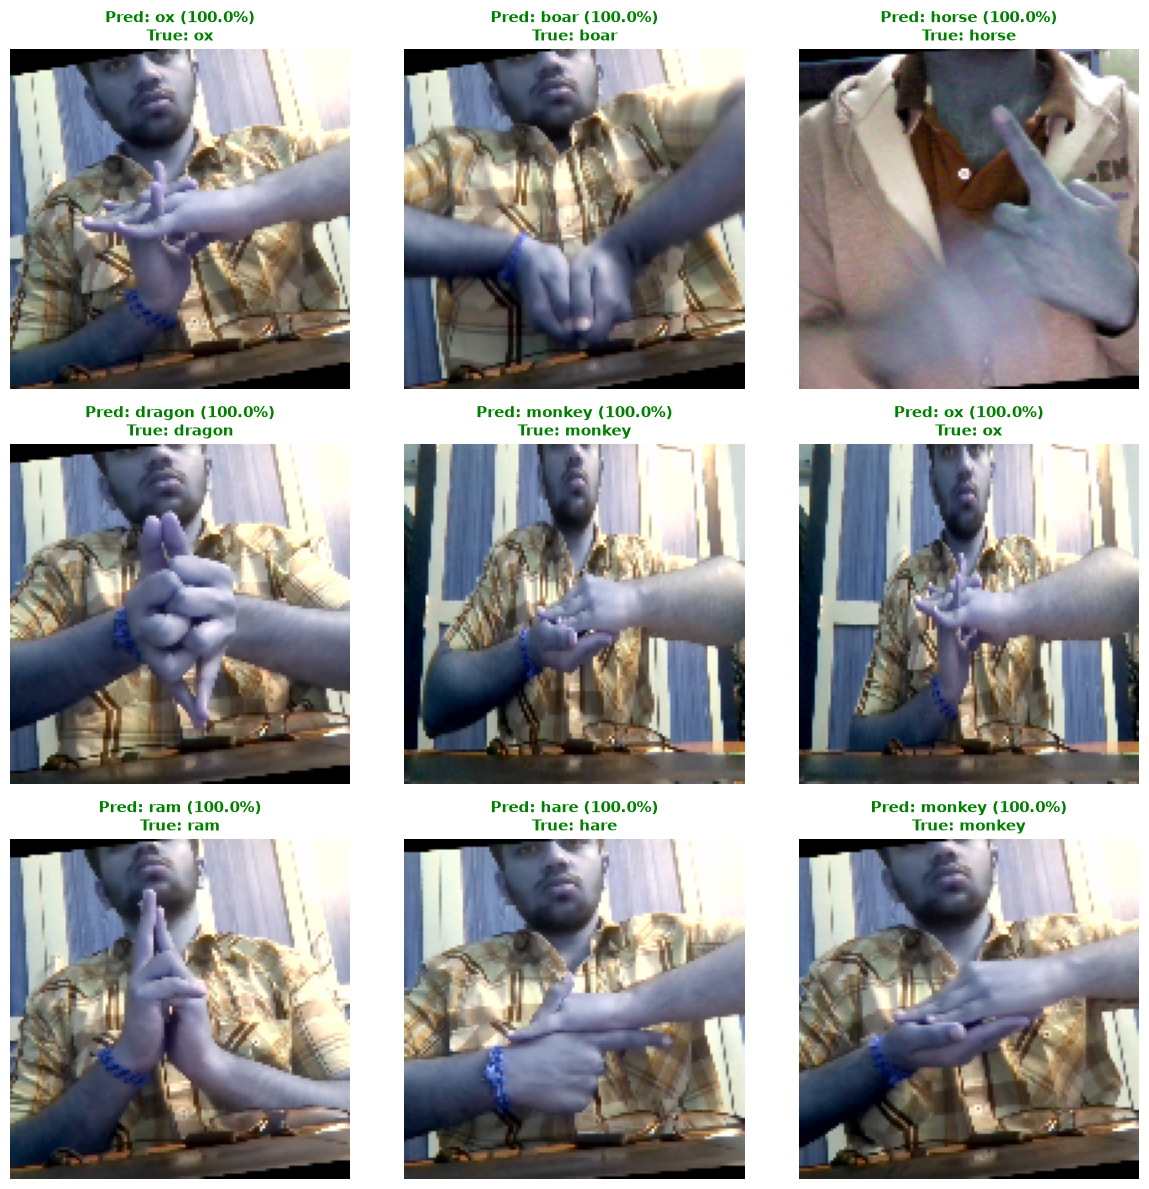

In [69]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_test_predictions(x_test, y_test, model, class_names, num_samples=9):
    """
    Predicts classes for the entire test split and visualizes a random grid of samples.
    
    Args:
        x_test (Tensor): Test images tensor, shape (N, 3, 128, 128)
        y_test (Tensor): Test labels tensor, shape (N,) containing class indices
        model (nn.Module): Trained PyTorch model instance
        class_names (list): List of class names corresponding to indices
        num_samples (int): Number of images to display in the grid (default: 9)
    """
    # 1. Setup device and evaluate entire test split
    device = next(model.parameters()).device
    model.eval()
    
    # Process the test data through the model on the correct device
    with torch.no_grad():
        # Move inputs to device and get raw logits
        inputs = x_test.to(device)
        outputs = model(inputs)
        
        # Calculate probabilities and extract the predicted indices
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)
        
        # Bring predictions back to CPU for numpy/matplotlib operations
        predictions = predictions.cpu().numpy()
        confidences = (confidences.cpu().numpy() * 100)
        true_labels = y_test.cpu().numpy()

    print(f"Evaluated all {len(x_test)} samples in the test split.")

    # 2. Setup the Matplotlib grid layout
    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    # 3. Select random indices to display from the test set
    random_indices = np.random.choice(len(x_test), size=num_samples, replace=False)

    for i, idx in enumerate(random_indices):
        # Extract image tensor and reshape back to (Height, Width, Channels) for plotting
        # PyTorch format: (3, 128, 128) -> Matplotlib format: (128, 128, 3)
        img_tensor = x_test[idx].permute(1, 2, 0).cpu().numpy()
        
        # Clip pixel values between [0, 1] just in case of floating-point inaccuracies
        img_tensor = np.clip(img_tensor, 0, 1)
        
        # Decode numeric indices to text strings
        pred_label = class_names[predictions[idx]]
        true_label = class_names[true_labels[idx]]
        conf = confidences[idx]
        
        # Determine text color: Green if correct, Red if incorrect
        is_correct = predictions[idx] == true_labels[idx]
        text_color = 'green' if is_correct else 'red'
        
        # Draw onto the grid subplot
        axes[i].imshow(img_tensor)
        axes[i].axis('off')
        
        title_text = f"Pred: {pred_label} ({conf:.1f}%)\nTrue: {true_label}"
        axes[i].set_title(title_text, color=text_color, fontsize=11, fontweight='bold')

    # Turn off any extra subplots if num_samples doesn't perfectly fill the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# --- How to Run It ---
# Ensure you are using the dynamic class list extracted from your directories
import os
train_dir = os.path.join("kaggle", "naruto-hand-signs", "data", "train")
my_classes = os.listdir(train_dir)

# Run the visualization grid
visualize_test_predictions(x_test, y_test, model, class_names=my_classes, num_samples=9)



Prediction: ram (99.50% confidence)
Prediction: ('ram', 99.49677586555481)


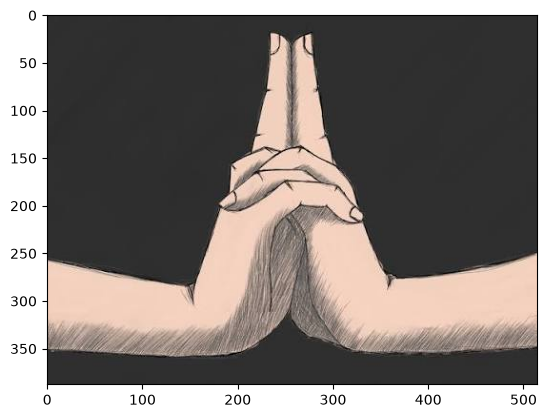

In [88]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict_custom_image(image_path, model, class_names=None):
    """
    Loads a custom image, preprocesses it, and predicts its class.
    
    Args:
        image_path (str): Path to your uploaded image (e.g., 'my_image.jpg')
        model (nn.Module): Your trained PyTorch Model instance
        class_names (list): Optional list of string labels matching class indices
    """
    # 1. Define the exact preprocessing transformation pipeline
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Matches your model's input size
        transforms.ToTensor(),          # Converts to tensor & normalizes to [0.0, 1.0]
    ])
    
    # 2. Open the image and ensure it has 3 channels (RGB)
    image = Image.open(image_path).convert('RGB')
    
    # 3. Apply transformations and add a batch dimension: [3, 128, 128] -> [1, 3, 128, 128]
    input_tensor = transform(image).unsqueeze(0)
    
    # 4. Set model to evaluation mode and move tensor to the correct device
    device = next(model.parameters()).device  # Automatically detects your model's current device
    input_tensor = input_tensor.to(device)
    model.eval()
    
    # 5. Run inference without calculating gradients
    with torch.no_grad():
        outputs = model(input_tensor)
        
        # Apply Softmax to get probabilities (since the model outputs raw logits)
        probabilities = torch.softmax(outputs, dim=1)
        
        # Get the index of the highest probability
        confidence, predicted_idx = torch.max(probabilities, 1)
        
        predicted_idx = predicted_idx.item()
        confidence = confidence.item() * 100  # Convert to percentage

    # 6. Print and return results
    if class_names and predicted_idx < len(class_names):
        print(f"Prediction: {class_names[predicted_idx]} ({confidence:.2f}% confidence)")
        return class_names[predicted_idx], confidence
    else:
        print(f"Prediction Class Index: {predicted_idx} ({confidence:.2f}% confidence)")
        return predicted_idx, confidence

# --- How to Run It ---
# Optional: Define your target text labels in order (0 to 9)

# multiple images predicting 


# Run the function on your uploaded file

path = 'testing-images/images.jpg'

image = cv2.imread(path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

pred = predict_custom_image(path, model, class_names=classes)
print("Prediction:", pred)
